Notebook 03: Data Preprocessing & Augmentation

In [3]:
from pathlib import Path

import random

import torch
from torch.utils.data import DataLoader

from torchvision import datasets
from torchvision import transforms

import matplotlib.pyplot as plt
print("Libaries Install")

Libaries Install


In [4]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

Device: cuda


In [5]:
PROJECT_ROOT = Path.cwd().parent

DATASET_ROOT = PROJECT_ROOT / "dataset" / "PlantVillage"

TRAIN_PATH = DATASET_ROOT / "train"
VAL_PATH = DATASET_ROOT / "val"

print(TRAIN_PATH)
print(VAL_PATH)

o:\Hackthons\KrishiOS\ai\dataset\PlantVillage\train
o:\Hackthons\KrishiOS\ai\dataset\PlantVillage\val


In [6]:
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 4

print(f"Image Size : {IMAGE_SIZE}")
print(f"Batch Size : {BATCH_SIZE}")

Image Size : 224
Batch Size : 32


In [7]:
train_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [8]:
val_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [9]:
train_dataset = datasets.ImageFolder(
    TRAIN_PATH,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    VAL_PATH,
    transform=val_transform
)

In [10]:
print("Training Images :", len(train_dataset))
print("Validation Images :", len(val_dataset))

print("Classes :", len(train_dataset.classes))

Training Images : 43444
Validation Images : 10861
Classes : 38


In [11]:
class_to_idx = train_dataset.class_to_idx

class_to_idx

{'Apple___Apple_scab': 0,
 'Apple___Black_rot': 1,
 'Apple___Cedar_apple_rust': 2,
 'Apple___healthy': 3,
 'Blueberry___healthy': 4,
 'Cherry_(including_sour)___Powdery_mildew': 5,
 'Cherry_(including_sour)___healthy': 6,
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7,
 'Corn_(maize)___Common_rust_': 8,
 'Corn_(maize)___Northern_Leaf_Blight': 9,
 'Corn_(maize)___healthy': 10,
 'Grape___Black_rot': 11,
 'Grape___Esca_(Black_Measles)': 12,
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13,
 'Grape___healthy': 14,
 'Orange___Haunglongbing_(Citrus_greening)': 15,
 'Peach___Bacterial_spot': 16,
 'Peach___healthy': 17,
 'Pepper,_bell___Bacterial_spot': 18,
 'Pepper,_bell___healthy': 19,
 'Potato___Early_blight': 20,
 'Potato___Late_blight': 21,
 'Potato___healthy': 22,
 'Raspberry___healthy': 23,
 'Soybean___healthy': 24,
 'Squash___Powdery_mildew': 25,
 'Strawberry___Leaf_scorch': 26,
 'Strawberry___healthy': 27,
 'Tomato___Bacterial_spot': 28,
 'Tomato___Early_blight': 29,
 'Toma

In [12]:
train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=True
)

val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=True
)

In [13]:
images, labels = next(iter(train_loader))

print(images.shape)

print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [14]:
train_dataset.classes

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [15]:
mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)

std = torch.tensor([0.229,0.224,0.225]).view(3,1,1)

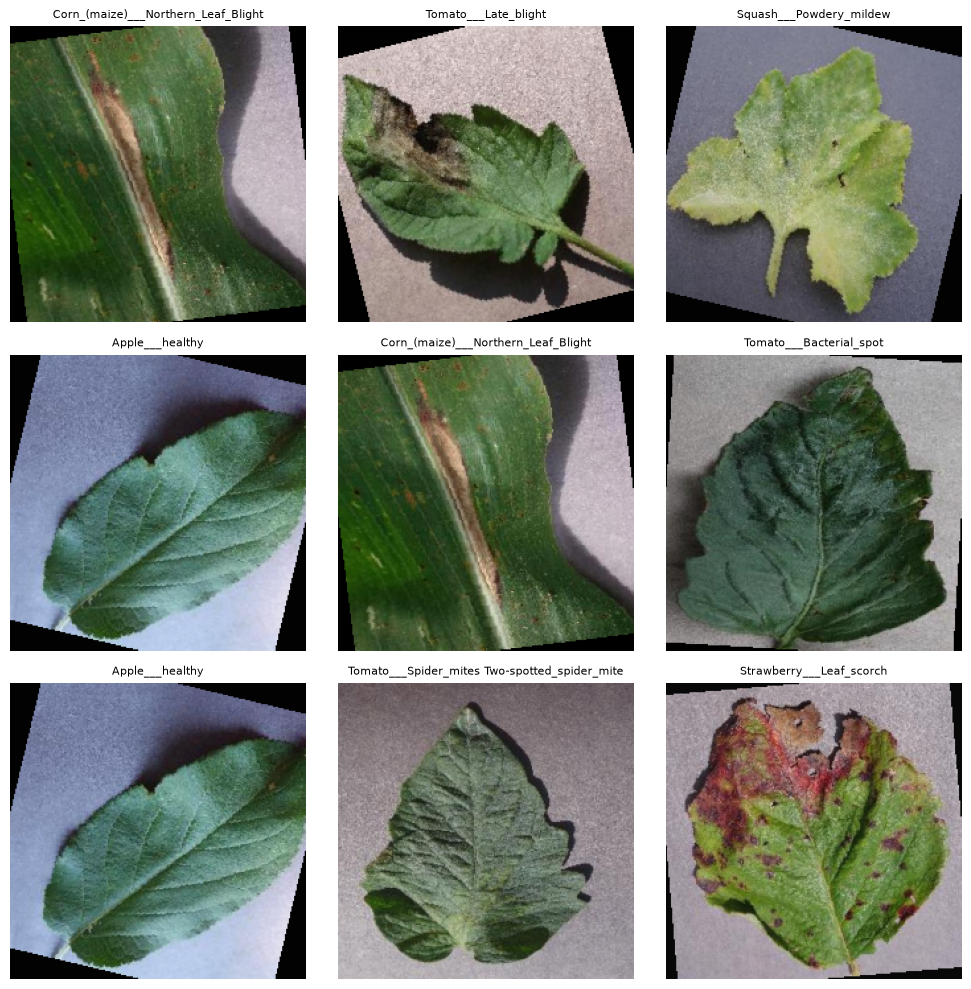

In [16]:
fig, axes = plt.subplots(3,3, figsize=(10,10))

for ax in axes.flat:

    idx = random.randint(0,BATCH_SIZE-1)

    img = images[idx]

    img = img * std + mean

    img = img.permute(1,2,0)

    ax.imshow(img)

    ax.set_title(
        train_dataset.classes[
            labels[idx]
        ],
        fontsize=8
    )

    ax.axis("off")

plt.tight_layout()

plt.show()

In [17]:
print("="*40)

print("Train batches :", len(train_loader))

print("Validation batches :", len(val_loader))

print("="*40)

Train batches : 1358
Validation batches : 340


In [18]:
print("✅ Dataset Ready")

print("Device :", DEVICE)

print("Classes :", len(train_dataset.classes))

print("Train Images :", len(train_dataset))

print("Validation Images :", len(val_dataset))

print("Batch Size :", BATCH_SIZE)

print("Image Size :", IMAGE_SIZE)

✅ Dataset Ready
Device : cuda
Classes : 38
Train Images : 43444
Validation Images : 10861
Batch Size : 32
Image Size : 224
